# UK Housing Price Analysis Using Machine Learning and Explainable AI

# Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Explainable AI
import shap

# Settings
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load Datasets

In [2]:
# Load UK House Price Dataset
housing = pd.read_csv("UK-HPI-full-file-2025-11.csv")

# Load Inflation Dataset
inflation = pd.read_csv("UK Inflation Rate.csv")

print("Housing Dataset Shape:", housing.shape)
print("Inflation Dataset Shape:", inflation.shape)

housing.head()

Housing Dataset Shape: (148680, 54)
Inflation Dataset Shape: (66, 2)


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,Detached12m%Change,SemiDetachedPrice,SemiDetachedIndex,SemiDetached1m%Change,SemiDetached12m%Change,TerracedPrice,TerracedIndex,Terraced1m%Change,Terraced12m%Change,FlatPrice,FlatIndex,Flat1m%Change,Flat12m%Change,CashPrice,CashIndex,Cash1m%Change,Cash12m%Change,CashSalesVolume,MortgagePrice,MortgageIndex,Mortgage1m%Change,Mortgage12m%Change,MortgageSalesVolume,FTBPrice,FTBIndex,FTB1m%Change,FTB12m%Change,FOOPrice,FOOIndex,FOO1m%Change,FOO12m%Change,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,130620.0,43.2,NaN,NaN,73972.0,40.9,NaN,NaN,58247.0,38.8,NaN,NaN,49322.0,45.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,129330.0,42.7,-1.0,NaN,74225.0,41.1,0.3,NaN,58669.0,39.1,0.7,NaN,50364.0,46.7,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,131585.0,43.5,1.7,NaN,76201.0,42.2,2.7,NaN,60399.0,40.2,2.9,NaN,51719.0,47.9,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,130454.0,43.1,-0.9,NaN,78082.0,43.2,2.5,NaN,62326.0,41.5,3.2,NaN,53143.0,49.2,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,132762.0,43.9,1.8,NaN,80340.0,44.5,2.9,NaN,64442.0,42.9,3.4,NaN,54678.0,50.7,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


# Initial Data Inspection

In [3]:
housing.info()
housing.describe()

# Check missing values
missing_values = housing.isnull().sum().sort_values(ascending=False)
print(missing_values.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148680 entries, 0 to 148679
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    148680 non-null  object 
 1   RegionName              148680 non-null  object 
 2   AreaCode                148680 non-null  object 
 3   AveragePrice            148680 non-null  int64  
 4   Index                   148680 non-null  float64
 5   IndexSA                 5229 non-null    float64
 6   1m%Change               148227 non-null  float64
 7   12m%Change              143820 non-null  float64
 8   AveragePriceSA          5229 non-null    float64
 9   SalesVolume             144213 non-null  float64
 10  DetachedPrice           141891 non-null  float64
 11  DetachedIndex           141891 non-null  float64
 12  Detached1m%Change       141496 non-null  float64
 13  Detached12m%Change      137175 non-null  float64
 14  SemiDetachedPrice   

# Data Cleaning

## Choosing Relevant Variables

In [4]:
columns_needed = [
    'Date',
    'RegionName',
    'AveragePrice',
    'SalesVolume',
    'DetachedPrice',
    'SemiDetachedPrice',
    'TerracedPrice',
    'FlatPrice',
    'CashPrice',
    'CashSalesVolume',
    'MortgagePrice',
    'MortgageSalesVolume',
    'FTBPrice'
]

housing = housing[columns_needed]

housing.head()

,Date,RegionName,AveragePrice,SalesVolume,DetachedPrice,SemiDetachedPrice,TerracedPrice,FlatPrice,CashPrice,CashSalesVolume,MortgagePrice,MortgageSalesVolume,FTBPrice
0,01/01/2004,Aberdeenshire,84638,388.0,130620.0,73972.0,58247.0,49322.0,NaN,NaN,NaN,NaN,NaN
1,01/02/2004,Aberdeenshire,84623,326.0,129330.0,74225.0,58669.0,50364.0,NaN,NaN,NaN,NaN,NaN
2,01/03/2004,Aberdeenshire,86536,453.0,131585.0,76201.0,60399.0,51719.0,NaN,NaN,NaN,NaN,NaN
3,01/04/2004,Aberdeenshire,87373,571.0,130454.0,78082.0,62326.0,53143.0,NaN,NaN,NaN,NaN,NaN
4,01/05/2004,Aberdeenshire,89493,502.0,132762.0,80340.0,64442.0,54678.0,NaN,NaN,NaN,NaN,NaN


## Convert Date Column

In [5]:
housing['Date'] = pd.to_datetime(housing['Date'])

housing['Year'] = housing['Date'].dt.year
housing['Month'] = housing['Date'].dt.month

## Merge Inflation Dataset

In [6]:
# Merge datasets using Year
data = pd.merge(housing, inflation, left_on='Year', right_on='year', how='left')

data.drop(columns=['year'], inplace=True)

data.head()

,Date,RegionName,AveragePrice,SalesVolume,DetachedPrice,SemiDetachedPrice,TerracedPrice,FlatPrice,CashPrice,CashSalesVolume,MortgagePrice,MortgageSalesVolume,FTBPrice,Year,Month,Inflation
0,2004-01-01,Aberdeenshire,84638,388.0,130620.0,73972.0,58247.0,49322.0,NaN,NaN,NaN,NaN,NaN,2004,1,1.390398
1,2004-01-02,Aberdeenshire,84623,326.0,129330.0,74225.0,58669.0,50364.0,NaN,NaN,NaN,NaN,NaN,2004,1,1.390398
2,2004-01-03,Aberdeenshire,86536,453.0,131585.0,76201.0,60399.0,51719.0,NaN,NaN,NaN,NaN,NaN,2004,1,1.390398
3,2004-01-04,Aberdeenshire,87373,571.0,130454.0,78082.0,62326.0,53143.0,NaN,NaN,NaN,NaN,NaN,2004,1,1.390398
4,2004-01-05,Aberdeenshire,89493,502.0,132762.0,80340.0,64442.0,54678.0,NaN,NaN,NaN,NaN,NaN,2004,1,1.390398


## Handling Missing Values

In [7]:
# Fill missing numeric values
numeric_columns = data.select_dtypes(include=np.number).columns

for col in numeric_columns:
    data[col].fillna(data[col].median(), inplace=True)

# Check again
data.isnull().sum().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_7228\2406954576.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


0

## Encode Region (Geographical Factor)

In [8]:
le = LabelEncoder()

data['RegionEncoded'] = le.fit_transform(data['RegionName'])

## Final Dataset for Modeling

In [9]:
features = [
    'SalesVolume',
    'DetachedPrice',
    'SemiDetachedPrice',
    'TerracedPrice',
    'FlatPrice',
    'CashSalesVolume',
    'MortgageSalesVolume',
    'FTBPrice',
    'Inflation',
    'RegionEncoded'
]

X = data[features]

y = data['AveragePrice']

# Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (118944, 10)
Testing size: (29736, 10)


# Exploratory Data Analysis (EDA)

## EDA 1: Correlation Matrix

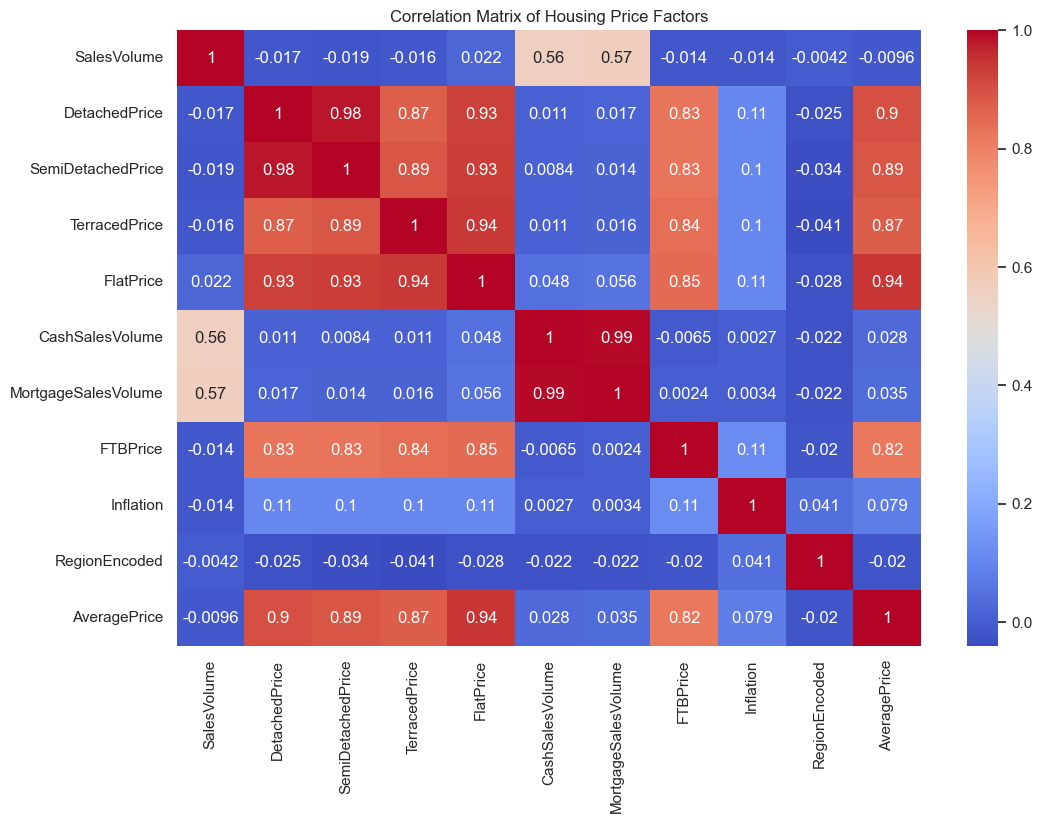

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data[features + ['AveragePrice']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix of Housing Price Factors")
plt.show()

## EDA 2: Housing Price Trend Over Time

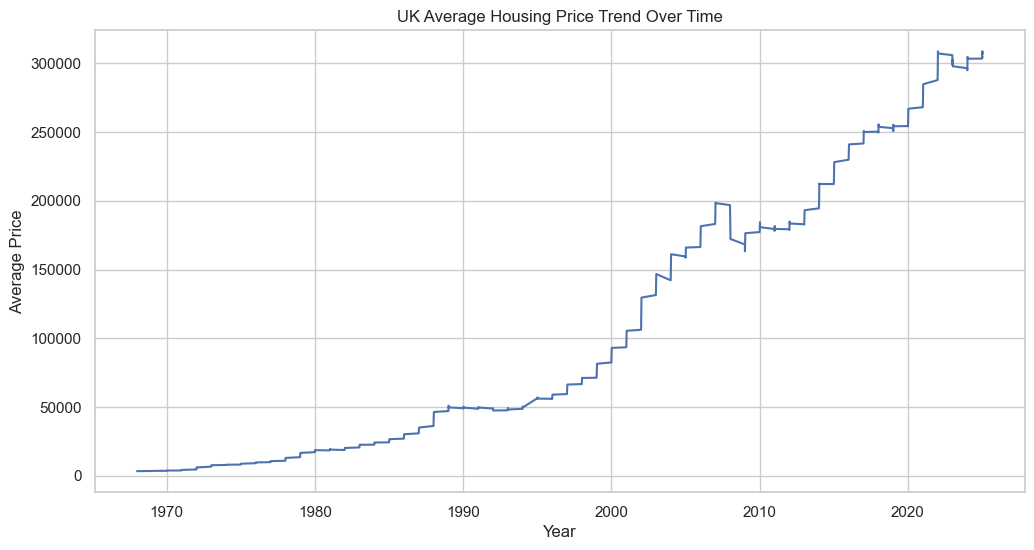

In [14]:
plt.figure(figsize=(12,6))

price_trend = data.groupby('Date')['AveragePrice'].mean()

plt.plot(price_trend)

plt.title("UK Average Housing Price Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.show()

## EDA 3: Housing Prices by Property Type

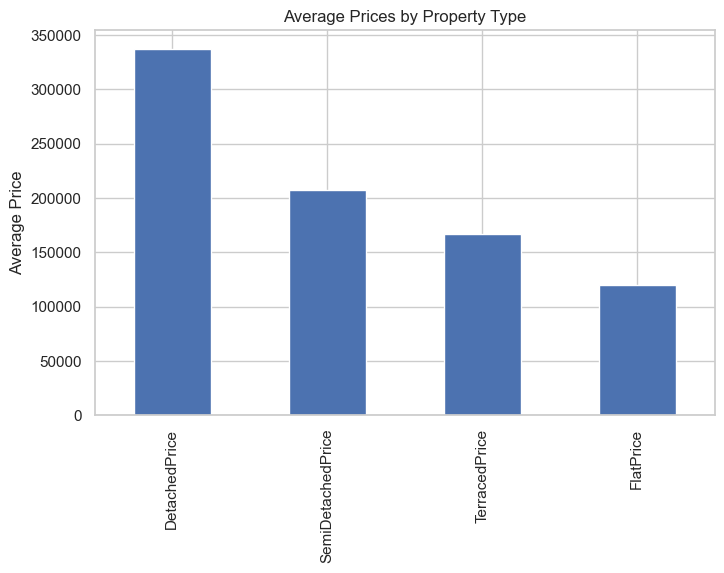

In [15]:
property_prices = data[[
    'DetachedPrice',
    'SemiDetachedPrice',
    'TerracedPrice',
    'FlatPrice'
]].mean()

property_prices.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Prices by Property Type")
plt.ylabel("Average Price")

plt.show()

## EDA 4: Housing Price Distribution

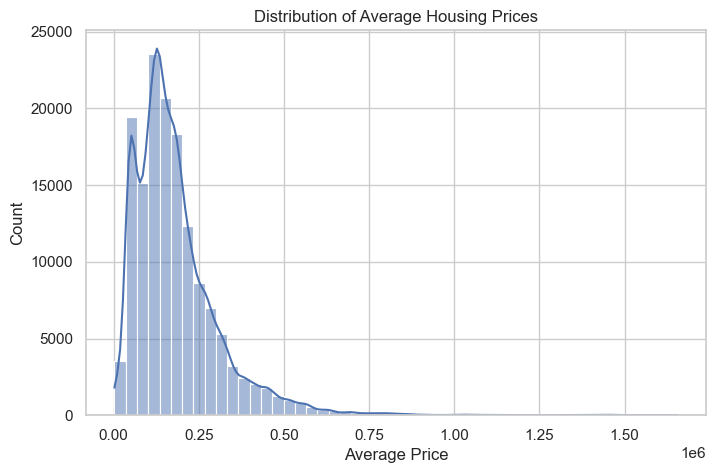

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(data['AveragePrice'], bins=50, kde=True)

plt.title("Distribution of Average Housing Prices")
plt.xlabel("Average Price")

plt.show()

## EDA 5: Regional Housing Price Comparison (Geographical Factor)

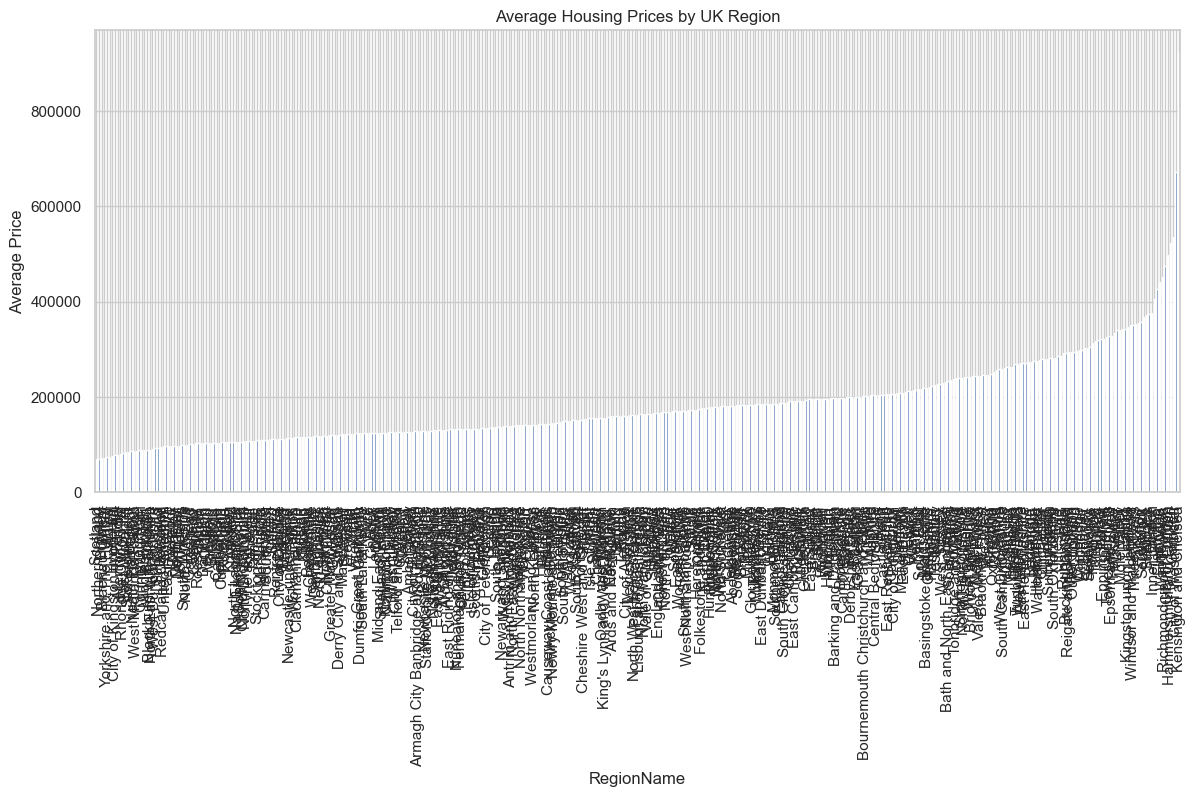

In [17]:
plt.figure(figsize=(14,6))

region_prices = data.groupby('RegionName')['AveragePrice'].mean().sort_values()

region_prices.plot(kind='bar')

plt.title("Average Housing Prices by UK Region")
plt.ylabel("Average Price")

plt.xticks(rotation=90)

plt.show()

## EDA 6: Inflation Rate vs Average Housing Price Over Time

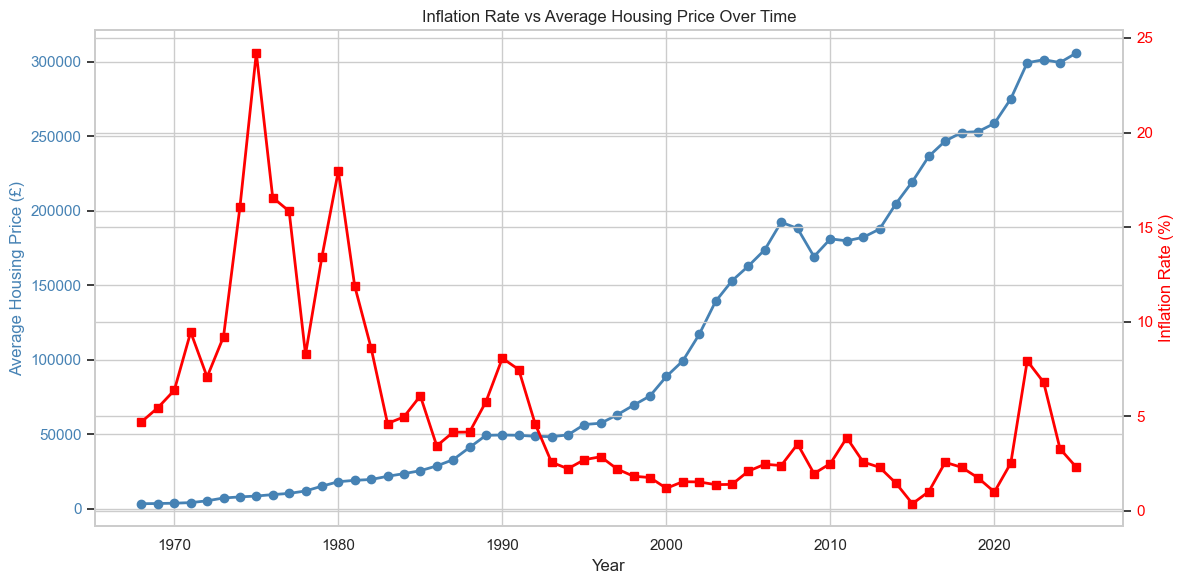

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))

yearly_data = data.groupby('Year').agg({
    'AveragePrice': 'mean',
    'Inflation': 'mean'
}).reset_index()

ax1.set_xlabel('Year')
ax1.set_ylabel('Average Housing Price (£)', color='steelblue')
ax1.plot(yearly_data['Year'], yearly_data['AveragePrice'], color='steelblue', linewidth=2, marker='o', label='Average Housing Price')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(yearly_data['Year'], yearly_data['Inflation'], color='red', linewidth=2, marker='s', label='Inflation Rate')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Inflation Rate vs Average Housing Price Over Time')
fig.tight_layout()
plt.show()

## EDA 7: Inflation Rate vs Average Price by Property Type

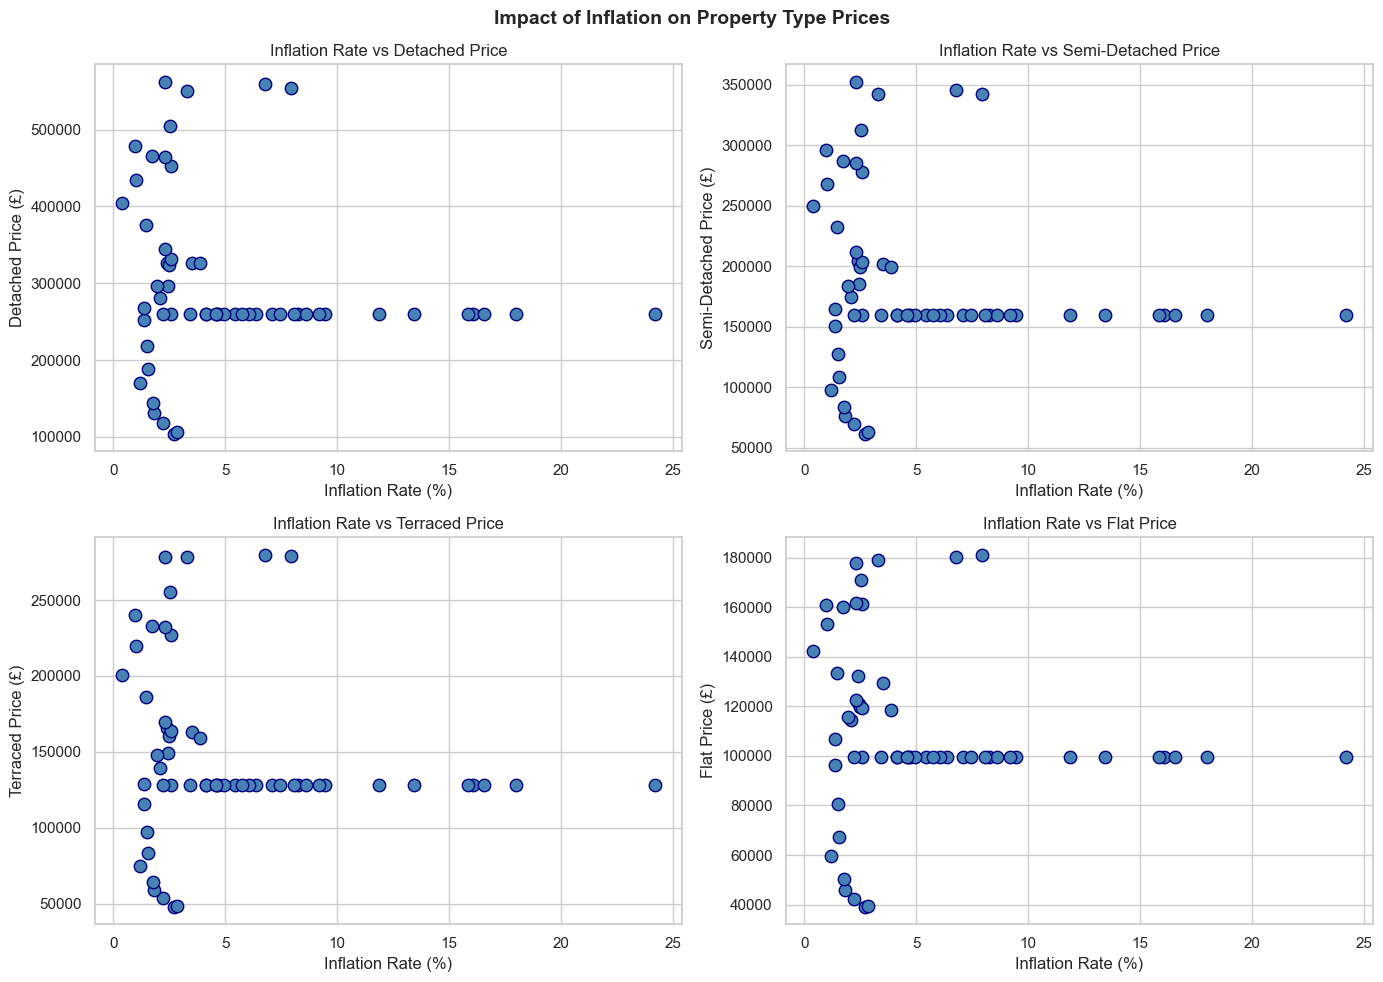

In [19]:
yearly_property = data.groupby('Year').agg({
    'DetachedPrice': 'mean',
    'SemiDetachedPrice': 'mean',
    'TerracedPrice': 'mean',
    'FlatPrice': 'mean',
    'Inflation': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
property_types = [('DetachedPrice', 'Detached'), ('SemiDetachedPrice', 'Semi-Detached'),
                  ('TerracedPrice', 'Terraced'), ('FlatPrice', 'Flat')]

for ax, (col, title) in zip(axes.flatten(), property_types):
    ax.scatter(yearly_property['Inflation'], yearly_property[col], color='steelblue', edgecolors='navy', s=80)
    ax.set_xlabel('Inflation Rate (%)')
    ax.set_ylabel(f'{title} Price (£)')
    ax.set_title(f'Inflation Rate vs {title} Price')

plt.suptitle('Impact of Inflation on Property Type Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EDA 8: Inflation Rate vs Buyer Type Prices

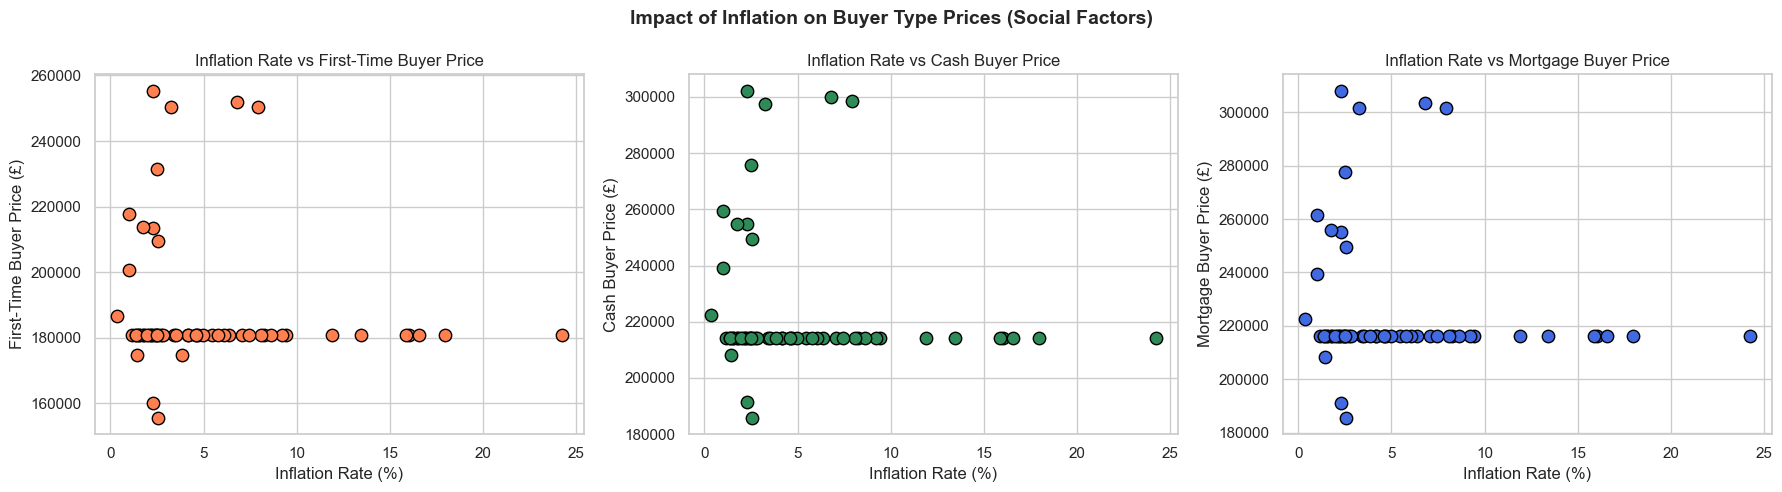

In [20]:
yearly_buyer = data.groupby('Year').agg({
    'FTBPrice': 'mean',
    'CashPrice': 'mean',
    'MortgagePrice': 'mean',
    'Inflation': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
buyer_types = [('FTBPrice', 'First-Time Buyer', 'coral'),
               ('CashPrice', 'Cash Buyer', 'seagreen'),
               ('MortgagePrice', 'Mortgage Buyer', 'royalblue')]

for ax, (col, title, color) in zip(axes, buyer_types):
    ax.scatter(yearly_buyer['Inflation'], yearly_buyer[col], color=color, edgecolors='black', s=80)
    ax.set_xlabel('Inflation Rate (%)')
    ax.set_ylabel(f'{title} Price (£)')
    ax.set_title(f'Inflation Rate vs {title} Price')

plt.suptitle('Impact of Inflation on Buyer Type Prices (Social Factors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Linear Regression Model

In [17]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Random Forest Model

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# XGBoost Model

In [19]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Model Evaluation (RMSE & MAE)

In [20]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("----------------------")


evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, xgb_pred, "XGBoost")

Linear Regression
MAE: 27872.237627813895
RMSE: 39893.46699739657
R2: 0.9058190877961806
----------------------
Random Forest
MAE: 2853.073296941675
RMSE: 4953.172978729172
R2: 0.9985481347161281
----------------------
XGBoost
MAE: 7384.48998586651
RMSE: 11080.857677551125
R2: 0.9927338211333666
----------------------


In [24]:
# Model evaluation results
models = ['Linear Regression', 'Random Forest', 'XGBoost']

MAE = [27872.2376, 2853.0733, 7384.4899]
RMSE = [39893.4670, 4953.1730, 11080.8577]
R2 = [0.9058, 0.9985, 0.9927]

# Create DataFrame
results = pd.DataFrame({
    'Model': models,
    'MAE': MAE,
    'RMSE': RMSE,
    'R2': R2
})

results.set_index('Model', inplace=True)

results

,MAE,RMSE,R2
Model,,,
Linear Regression,27872.2376,39893.4670,0.9058
Random Forest,2853.0733,4953.1730,0.9985
XGBoost,7384.4899,11080.8577,0.9927


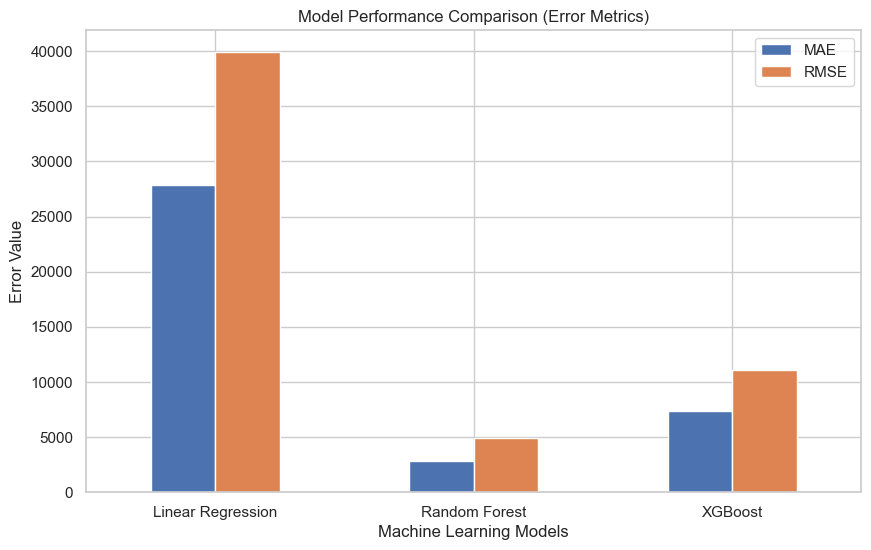

In [25]:
results[['MAE','RMSE']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison (Error Metrics)")
plt.ylabel("Error Value")
plt.xlabel("Machine Learning Models")

plt.xticks(rotation=0)

plt.show()

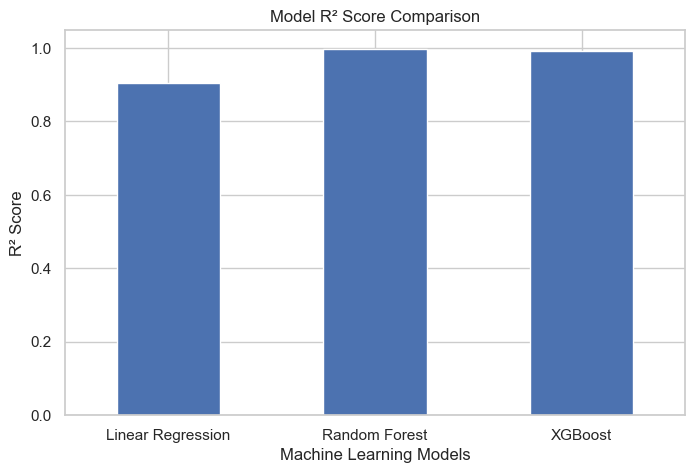

In [26]:
results['R2'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Machine Learning Models")

plt.xticks(rotation=0)

plt.show()

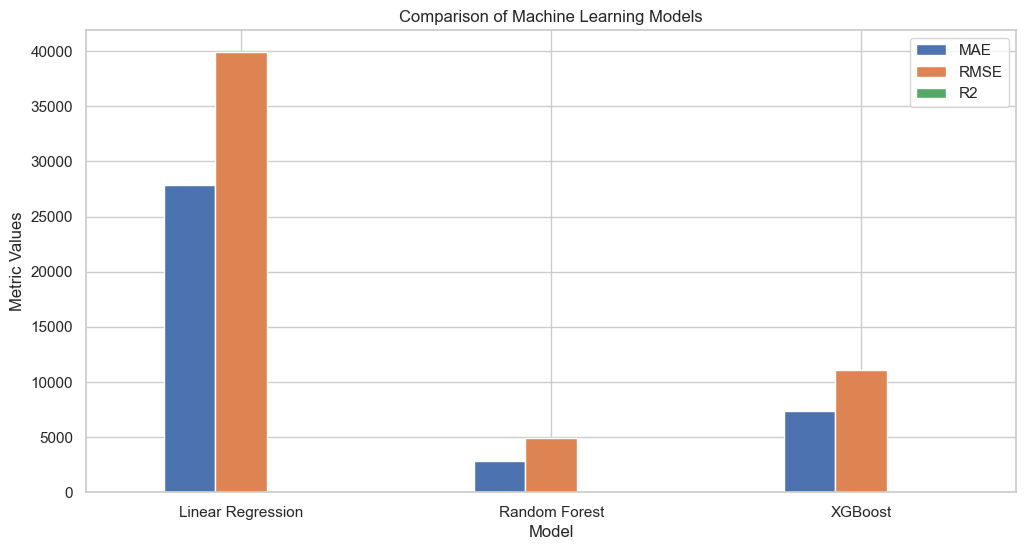

In [27]:
results.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Metric Values")

plt.xticks(rotation=0)

plt.show()

# Feature Importance

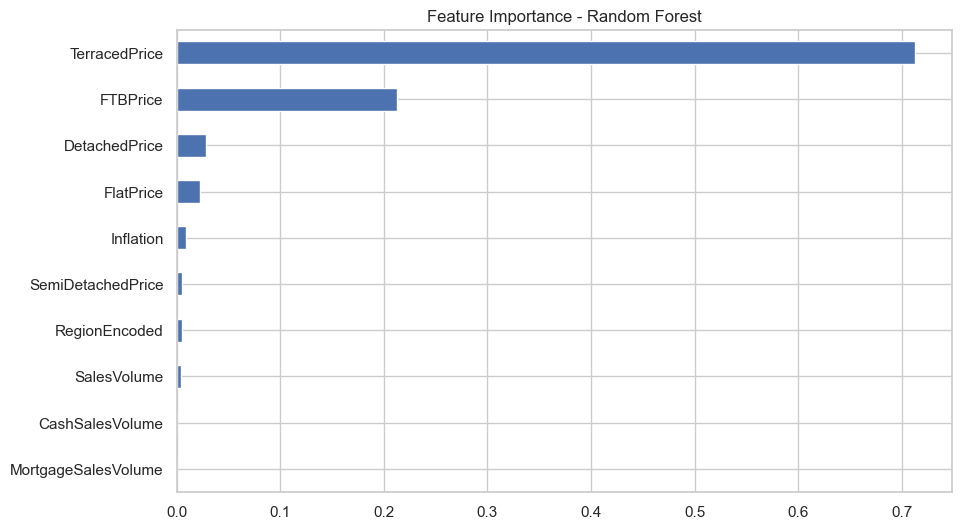

In [21]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance - Random Forest")
plt.show()

# Explainable AI using SHAP

In [22]:
explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

# SHAP Summary Plot

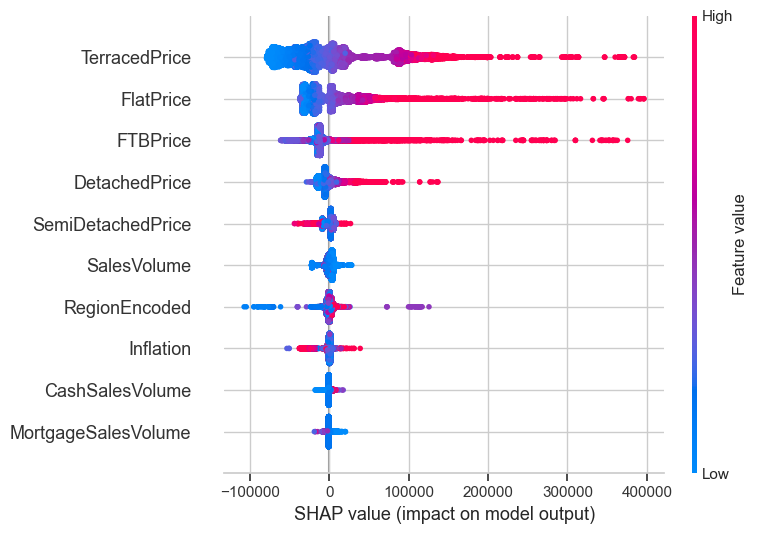

In [23]:
shap.summary_plot(shap_values, X_test)